Note:
To train the model, run the whole notebook.
To only visualize the model, run the first cell and the second cell to load the model structure and data. Then run the last cell to visualize the predictions.

Model definition.

In [3]:
import os

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler

from torch.utils.data import DataLoader, TensorDataset
torch.backends.cudnn.enabled = False

BATCH_SIZE = 64
LEARNING_RATE = 0.001
HIDDEN_SIZE = 256
NUM_LAYERS = 2
DROPOUT = 0
WINDOW_SIZE = 60
EARLY_STOP_PATIENCE = 20
MODEL_SAVE_PATH_LAST = "../../models/multidim_LSTM_last.pth"
MODEL_SAVE_PATH_BEST = "../../models/multidim_LSTM_best.pth"
TRAIN_RATIO = 0.8
VAL_RATIO = 0.9


class FeatureAttentionLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # Feature attention：输入是 x_t + h_{t-1}，输出是特征权重
        self.feature_attn = nn.Linear(input_size + hidden_size, input_size)
        
        # LSTM接收加权后的特征
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, dropout=0.2, batch_first=True)
        self.activation = nn.ReLU()
        self.fc = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        batch_size, seq_len, input_size = x.shape
        
        h = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(x.device)
        c = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(x.device)
        
        outputs = []
        for t in range(seq_len):
            x_t = x[:, t, :]          # (batch, input_size)

            # get h_{t-1} from the last layer (what we have so far)
            h_prev = h[-1]
            
            attn_input = torch.cat([x_t, h_prev], dim=-1)   # (batch, input_size + hidden_size)
            atten_score = self.feature_attn(attn_input)       # (batch, input_size)
            attn_weights = torch.softmax(atten_score, dim=-1)  # (batch, input_size)
            
            x_weighted = attn_weights * x_t                  # (batch, input_size)
            
            x_weighted = x_weighted.unsqueeze(1)             # (batch, 1, input_size)
            out, (h, c) = self.lstm(x_weighted, (h, c))
            outputs.append(out)
        
        # 取最后一步输出
        last_out = outputs[-1].squeeze(1)   # (batch, hidden_size)
        last_out = self.activation(last_out)
        h.detach_()
        c.detach_()
        
        return self.fc(last_out)


def build_windows(data: np.ndarray, window_size: int) -> tuple[np.ndarray, np.ndarray]:
    """Build sliding-window (X, y) pairs. y is the value immediately after the window (one-step-ahead)."""
    x, y = [], []
    for i in range(len(data) - window_size):
        x.append(data[i : i + window_size])
        y.append([data[i + window_size][0]])  # predict the first feature (NASDAQCOM) only
    return (
        np.array(x),
        np.array(y),
    )

def get_daily_percentage_change(data: np.ndarray) -> np.ndarray:
    result = np.zeros(len(data))
    for i in range(1, len(data)):
        if data[i - 1] != 0:
            result[i] = ((data[i] - data[i - 1]) / data[i - 1])
    result[0] = 0
    return result

def get_device():
    if torch.cuda.is_available():
        print("Using CUDA")
        return torch.device("cuda")
    else:
        print("Using CPU")
        return torch.device("cpu")

def get_data():
    df_nsdq = pd.read_csv("../../datasets_aligned/NASDAQCOM.csv")
    df_gpr = pd.read_csv("../../datasets_aligned/data_gpr_daily_recent.CSV")
    df_interest = pd.read_csv("../../datasets_aligned/DFF_interest_rate.csv")

    start_date = pd.Timestamp("1985-01-01")
    end_date = pd.Timestamp("2025-10-01")

    df_nsdq.index = pd.to_datetime(df_nsdq["date"])
    df_gpr.index = pd.to_datetime(df_gpr["date"])
    df_interest.index = pd.to_datetime(df_interest["date"])

    df_nsdq = df_nsdq.loc[start_date:end_date]
    df_gpr = df_gpr.loc[start_date:end_date]
    df_interest = df_interest.loc[start_date:end_date]

    data_nsdq = np.array(df_nsdq["NASDAQCOM"].values, dtype=np.float32)
    data_gpr = np.array(df_gpr["gpr"].values, dtype=np.float32)
    data_interest = np.array(df_interest["DFF"].values, dtype=np.float32)
    
    # 计算百分比变化
    data_nsdq = get_daily_percentage_change(data_nsdq)
    data_gpr = data_gpr / 1000 # scale down GPR
    data_interest = data_interest / 100 # scale down interest rates

    # 合并特征并进行标准化
    raw_data = np.column_stack((data_nsdq, data_gpr, data_interest))
    
    # 标准化（保存scaler用于后续inference）
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(raw_data)
    
    return scaled_data, np.array(df_nsdq["date"].values), scaler


Data loading.

In [4]:
device = get_device()

data, dates, scaler = get_data()

print("数据形状:", data.shape)
print("特征数:", data.shape[1])
print("\n特征统计:")
print(f"NASDAQ - mean: {data[:, 0].mean():.4f}, std: {data[:, 0].std():.4f}")
print(f"GPR - mean: {data[:, 1].mean():.4f}, std: {data[:, 1].std():.4f}")
print(f"Interest Rate - mean: {data[:, 2].mean():.4f}, std: {data[:, 2].std():.4f}")

train_end = int(len(data) * TRAIN_RATIO)
val_start = train_end - WINDOW_SIZE - 1
val_end = int(len(data) * VAL_RATIO)
test_start = val_end - WINDOW_SIZE - 1


train_x, train_y = build_windows(data[:train_end], WINDOW_SIZE)
val_x, val_y = build_windows(data[val_start:val_end], WINDOW_SIZE)
test_x, test_y = build_windows(data[test_start:], WINDOW_SIZE)

test_dates = dates[test_start + WINDOW_SIZE : test_start + WINDOW_SIZE + len(test_y)]

train_x = torch.tensor(train_x, dtype=torch.float32)
train_y = torch.tensor(train_y, dtype=torch.float32)
val_x = torch.tensor(val_x, dtype=torch.float32)
val_y = torch.tensor(val_y, dtype=torch.float32)
test_x = torch.tensor(test_x, dtype=torch.float32)
test_y = torch.tensor(test_y, dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(train_x, train_y),
    batch_size=BATCH_SIZE,
    shuffle=True,
)
val_loader = DataLoader(
    TensorDataset(val_x, val_y),
    batch_size=BATCH_SIZE,
    shuffle=False,
)
test_loader = DataLoader(
    TensorDataset(test_x, test_y),
    batch_size=BATCH_SIZE,
    shuffle=False,
)


Using CUDA
数据形状: (14884, 3)
特征数: 3

特征统计:
NASDAQ - mean: 0.0000, std: 1.0000
GPR - mean: -0.0000, std: 1.0000
Interest Rate - mean: -0.0000, std: 1.0000


Model Training.

In [ ]:

mse_loss_fn = nn.MSELoss()
direction_loss_fn = nn.BCEWithLogitsLoss()

def criterion(preds, targets):
    mse_loss = mse_loss_fn(preds, targets)
    variance_loss = torch.var(targets) - torch.var(preds)
    return mse_loss + 0.5 * variance_loss
model = FeatureAttentionLSTM(input_size=3, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS).to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

best_val_loss = float("inf")
best_model_state = None
no_improve_count = 0
epoch = 0

user_saved_model = None


while no_improve_count < EARLY_STOP_PATIENCE:

    try:
        # training
        model.train()
        train_loss = 0.0
        for inputs, targets in train_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, targets)
            optimizer.zero_grad()
            loss.backward()
            #torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)
        print(f"Epoch {epoch}, Train Loss: {train_loss:.6f}", end="")
        
        # validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs = inputs.to(device)
                targets = targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss += loss.item()
        val_loss /= len(val_loader)
        print(f", Val Loss: {val_loss:.6f}")

        user_saved_model = {k: v.detach().cpu() for k, v in model.state_dict().items()}
        if val_loss < best_val_loss and epoch >= 10:  # allow some epochs for initial convergence
            best_val_loss = val_loss
            best_model_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}
            no_improve_count = 0
        else:
            no_improve_count += 1
        epoch += 1
    except KeyboardInterrupt:
        print("Early stopping triggered by user.")
        break




Using CUDA
数据形状: (14884, 3)
特征数: 3

特征统计:
NASDAQ - mean: 0.0000, std: 1.0000
GPR - mean: -0.0000, std: 1.0000
Interest Rate - mean: -0.0000, std: 1.0000
Epoch 0, Train Loss: 1.458881, Val Loss: 1.522231
Epoch 1, Train Loss: 1.458800, Val Loss: 1.529119
Epoch 2, Train Loss: 1.452018, Val Loss: 1.529799
Epoch 3, Train Loss: 1.451505, Val Loss: 1.542952
Epoch 4, Train Loss: 1.442737, Val Loss: 1.525518
Epoch 5, Train Loss: 1.438448, Val Loss: 1.542172
Epoch 6, Train Loss: 1.434670, Val Loss: 1.530752
Epoch 7, Train Loss: 1.428417, Val Loss: 1.527893
Epoch 8, Train Loss: 1.424906, Val Loss: 1.541156
Epoch 9, Train Loss: 1.450331, Val Loss: 1.532802
Epoch 10, Train Loss: 1.461106, Val Loss: 1.544072
Epoch 11, Train Loss: 1.461984, Val Loss: 1.538499
Epoch 12, Train Loss: 1.458317, Val Loss: 1.530609
Epoch 13, Train Loss: 1.462185, Val Loss: 1.535030
Epoch 14, Train Loss: 1.454264, Val Loss: 1.528845
Epoch 15, Train Loss: 1.459215, Val Loss: 1.532180
Epoch 16, Train Loss: 1.435705, Val Loss:

Run the following code to save the model.

Do not run the code if you have already saved the model, as it will overwrite the existing model file.

In [35]:
print(f"\ntraining completed in {epoch} epochs")
print(f"best validation loss: {best_val_loss:.6f}")
print(f"best model saved to {MODEL_SAVE_PATH_BEST}")
print(f"last model saved to {MODEL_SAVE_PATH_LAST}")

os.makedirs("models", exist_ok=True)
torch.save(best_model_state, MODEL_SAVE_PATH_BEST)
torch.save(user_saved_model, MODEL_SAVE_PATH_LAST)


training completed in 44 epochs
best validation loss: 1.522391
best model saved to ../../models/multidim_LSTM_best.pth
last model saved to ../../models/multidim_LSTM_last.pth


Run the following code to load the model and visualize the predictions.


=== predictions distribution ===
squared error: 0.00000773
max: 0.011463
min: -0.015499
mean: 0.000248
std: 0.002781
range: [-0.0155, 0.0115]

=== target distribution ===
squared error: 0.00013456
max: 0.121632
min: -0.059681
mean: 0.000332
std: 0.011600
range: [-0.0597, 0.1216]


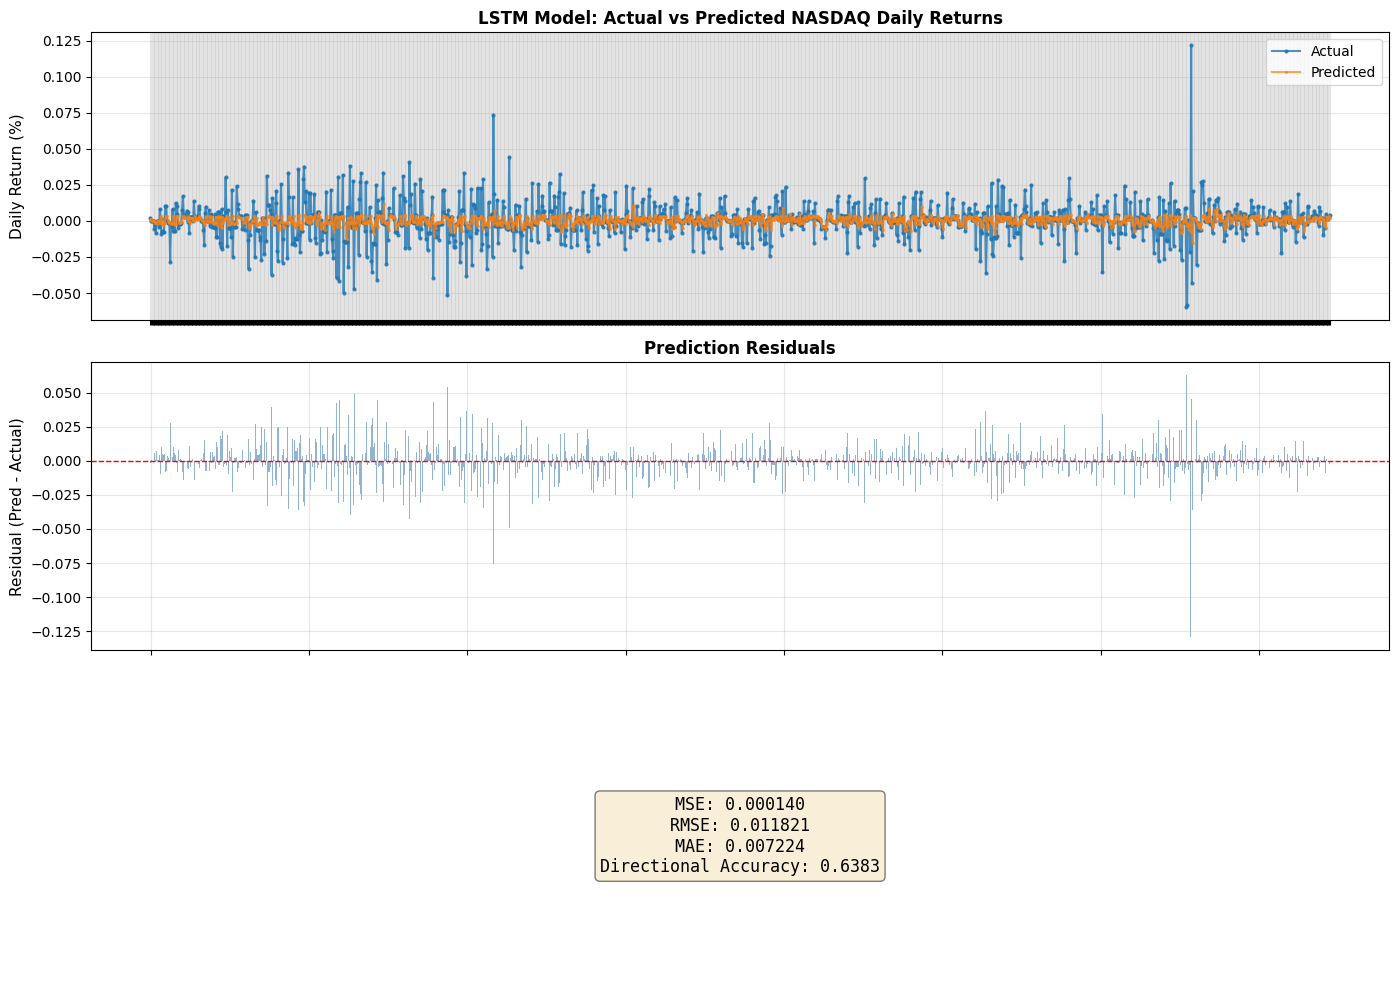


=== Model Performance ===
MSE: 0.000140
RMSE: 0.011821
MAE: 0.007224
Directional Accuracy: 0.6383


In [5]:
import matplotlib.pyplot as plt

model = FeatureAttentionLSTM(input_size=3, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS).to(device)

model.load_state_dict(torch.load(MODEL_SAVE_PATH_LAST))

model.eval()

all_preds = []
all_targets = []
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        all_preds.append(outputs.squeeze(-1).cpu().numpy())
        all_targets.append(targets.squeeze(-1).numpy())

preds_scaled = np.concatenate(all_preds)
targets_scaled = np.concatenate(all_targets)

# we only denormalize the NASDAQ predictions and targets, the other features are not used for evaluation
dummy_features = np.zeros((len(preds_scaled), 3)) # (num_samples, num_features)
dummy_features[:, 0] = preds_scaled
preds = scaler.inverse_transform(dummy_features)[:, 0] # (num_samples) denormalized predictions

dummy_features_targets = np.zeros((len(targets_scaled), 3)) # (num_samples, num_features)
dummy_features_targets[:, 0] = targets_scaled
targets = scaler.inverse_transform(dummy_features_targets)[:, 0] # (num_samples) denormalized targets

print("\n=== predictions distribution ===")
print(f"squared error: {np.var(preds):.8f}")
print(f"max: {np.max(preds):.6f}")
print(f"min: {np.min(preds):.6f}")
print(f"mean: {np.mean(preds):.6f}")
print(f"std: {np.std(preds):.6f}")
print(f"range: [{np.min(preds):.4f}, {np.max(preds):.4f}]")

print(f"\n=== target distribution ===")
print(f"squared error: {np.var(targets):.8f}")
print(f"max: {np.max(targets):.6f}")
print(f"min: {np.min(targets):.6f}")
print(f"mean: {np.mean(targets):.6f}")
print(f"std: {np.std(targets):.6f}")
print(f"range: [{np.min(targets):.4f}, {np.max(targets):.4f}]")

# Create comprehensive visualization
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Plot 1: Predictions vs Actual
axes[0].plot(test_dates, targets, label="Actual", linewidth=1.5, alpha=0.8, marker='o', markersize=2)
axes[0].plot(test_dates, preds, label="Predicted", linewidth=1.5, alpha=0.7, marker='s', markersize=1)
axes[0].set_ylabel("Daily Return (%)", fontsize=11)
axes[0].set_title("LSTM Model: Actual vs Predicted NASDAQ Daily Returns", fontsize=12, fontweight='bold')
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)

# Plot 2: Residuals
residuals = preds - targets
axes[1].bar(range(len(residuals)), residuals, color='steelblue', alpha=0.6, width=1.0)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_ylabel("Residual (Pred - Actual)", fontsize=11)
axes[1].set_title("Prediction Residuals", fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Plot 3: Metrics
mse = np.mean((preds - targets)**2)
mae = np.mean(np.abs(preds - targets))
rmse = np.sqrt(mse)
directional_correct = np.sum(((preds > 0) & (targets > 0)) | ((preds < 0) & (targets < 0)))
directional_accuracy = directional_correct / len(preds)

metrics_text = f"MSE: {mse:.6f}\nRMSE: {rmse:.6f}\nMAE: {mae:.6f}\nDirectional Accuracy: {directional_accuracy:.4f}"
axes[2].text(0.5, 0.5, metrics_text, fontsize=12, ha='center', va='center',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5), family='monospace')
axes[2].axis('off')

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

print(f"\n=== Model Performance ===")
print(f"MSE: {mse:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"MAE: {mae:.6f}")
print(f"Directional Accuracy: {directional_accuracy:.4f}")